# 01 — Data Preparation & Exploratory Analysis
## Kindle Store (Amazon Reviews 2023)

**Project:** Real-time recommendation system — retrieval (MF-BPR, two-tower) + ranking (LightGBM) + serving webapp.

**This notebook covers:** download → subsampling → 5-core filtering → positive-interaction definition → **time-based split** → EDA → export of processed splits.

### Why Kindle Store?

We chose the Kindle Store category of Amazon Reviews 2023 (McAuley Lab) for one main reason: **density**. Kindle readers are repeat users (~4.6 ratings/user on average vs ~1–2 for most Amazon categories). Collaborative filtering fundamentally relies on users co-interacting with multiple items — a denser user side means MF-BPR and the two-tower model have real signal to learn from, and it gives us a meaningful spread of user activity levels for the cold-start analysis required in `ANALYSIS.md`.

Trade-offs we accept and handle below:
- **25.3M ratings** → above the 5M project cap → we subsample (Section 2).
- **1.6M items** → heavy catalog → the 5-core filter (Section 3) also shrinks the item side to items with enough interactions to be learnable and servable.

## 0. Setup

Runs on Google Colab (free T4 is enough — this notebook is CPU-only). Artifacts are saved to Google Drive so they survive session timeouts.

In [1]:
import os, gzip, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

# --- Paths: Google Drive if on Colab, local ./data otherwise ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/recsys_kindle/data'
except ImportError:
    DATA_DIR = './data'
os.makedirs(DATA_DIR, exist_ok=True)

# --- Config (design decisions, referenced throughout) ---
N_SUBSAMPLE   = 5_000_000   # project cap: most recent 5M interactions
K_CORE        = 5           # min interactions per user AND per item
POS_THRESHOLD = 4.0         # rating >= 4 counts as a positive (justified in Section 4)
TRAIN_Q, VAL_Q = 0.80, 0.90 # time-based split: 80% train / 10% val / 10% test by timestamp

print('Data dir:', DATA_DIR)

Matplotlib is building the font cache; this may take a moment.


Data dir: ./data


## 1. Download

We use the **0-core "ratings only"** file provided by the dataset authors: `user_id, parent_asin, rating, timestamp`. It is already de-duplicated, and at ~4 columns it is far lighter than the full review JSONL (~26M rows of review text we don't need at this stage). Review text and item metadata (titles, images, categories — needed for the webapp and for ranking features) will be pulled in later notebooks, filtered to the items that survive preprocessing here.

Note: `parent_asin` is the correct item ID — variants (editions, formats) share one parent, and item metadata is keyed on it.

In [2]:
RATINGS_URL = 'https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/benchmark/0core/rating_only/Kindle_Store.csv.gz'
ratings_path = os.path.join(DATA_DIR, 'Kindle_Store.csv.gz')

if not os.path.exists(ratings_path):
    print('Downloading (~350MB)...')
    urllib.request.urlretrieve(RATINGS_URL, ratings_path)
print('File size: %.1f MB' % (os.path.getsize(ratings_path) / 1e6))

File size: 464.5 MB


In [3]:
df = pd.read_csv(
    ratings_path,
    dtype={'user_id': 'string', 'parent_asin': 'string', 'rating': 'float32', 'timestamp': 'int64'},
)
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')

print(f'{len(df):,} interactions | {df.user_id.nunique():,} users | {df.parent_asin.nunique():,} items')
print('Time span:', df.datetime.min(), '->', df.datetime.max())
df.head()

25,302,305 interactions | 5,646,991 users | 1,590,697 items
Time span: 1999-08-28 22:48:32 -> 2023-09-13 20:23:18.464000


,user_id,parent_asin,rating,timestamp,datetime
0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B00LXRJICK,5.0,1427541413000,2015-03-28 11:16:53.000
1,AHGTHCERTEZUXNBLJ5SWHK2CDLXA,B073DFP8VC,3.0,1504226946142,2017-09-01 00:49:06.142
2,AHFY2QSS6PK5MHSYZFI6TXUYNPLQ,B004Y1NWQU,5.0,1363027885000,2013-03-11 18:51:25.000
3,AHFY2QSS6PK5MHSYZFI6TXUYNPLQ,B07QVH25KX,5.0,1644883955777,2022-02-15 00:12:35.777
4,AFWHJ6O3PV4JC7PVOJH6CPULO2KQ,B00EMXBDMA,3.0,1402838575000,2014-06-15 13:22:55.000


## 2. Subsampling: most recent 5M interactions

**Design decision.** The project spec caps datasets at 5M interactions and asks us to keep the *most recent* ones. We sort by timestamp and keep the last 5M rather than sampling randomly across 27 years, because:

1. **Recency = relevance.** A recommender trained on 2001 Kindle behavior tells us nothing useful for serving in 2023. Recent data matches the distribution the webapp will actually serve.
2. **Temporal continuity.** Random subsampling across years would shred user histories into disconnected fragments; a contiguous recent window preserves realistic session/history structure, which the time-based split (Section 5) depends on.
3. **Density bonus.** Kindle volume grew over time, so the recent window covers a shorter period at higher intensity — more co-interaction per user/item.

In [4]:
df = df.sort_values('timestamp', kind='mergesort').tail(N_SUBSAMPLE).reset_index(drop=True)

print(f'After subsampling: {len(df):,} interactions')
print('Window:', df.datetime.min(), '->', df.datetime.max())
print(f'Users: {df.user_id.nunique():,} | Items: {df.parent_asin.nunique():,}')

After subsampling: 5,000,000 interactions
Window: 2020-10-20 02:19:53.567000 -> 2023-09-13 20:23:18.464000


Users: 1,232,672 | Items: 608,525


## 3. 5-core filtering

**Design decision.** We keep only users and items with **≥ 5 interactions**, applied *iteratively* (removing sparse items can push a user below 5, and vice versa — we loop until stable).

Why: a user with 1–2 interactions contributes almost nothing to learning a user embedding, and an item bought twice cannot be reliably recommended or evaluated. This is standard practice (the dataset authors publish 5-core versions themselves — we re-derive it *after* subsampling so the two steps compose correctly).

Cost to acknowledge at the defense: k-core biases the dataset toward active users/popular items. That's exactly why the cold-start section of `ANALYSIS.md` breaks performance down by user activity level (5–10 vs 11–50 vs >50 interactions) — the *relative* cold users are still there. Note also that this filtering happens before the time-based split (Section 5) — a user's inclusion in val/test therefore reflects their total activity across the full window, not just their pre-split history, a minor (and standard) leak we accept for a class project rather than re-deriving per-split cores.

In [5]:
def k_core(frame, k):
    i = 0
    while True:
        i += 1
        n0 = len(frame)
        vc_u = frame.user_id.value_counts()
        frame = frame[frame.user_id.isin(vc_u[vc_u >= k].index)]
        vc_i = frame.parent_asin.value_counts()
        frame = frame[frame.parent_asin.isin(vc_i[vc_i >= k].index)]
        print(f'  iter {i}: {n0:,} -> {len(frame):,}')
        if len(frame) == n0:
            return frame

df = k_core(df, K_CORE).reset_index(drop=True)

n_u, n_i = df.user_id.nunique(), df.parent_asin.nunique()
print(f'\nFinal: {len(df):,} interactions | {n_u:,} users | {n_i:,} items')
print(f'Avg interactions/user: {len(df)/n_u:.1f} | /item: {len(df)/n_i:.1f}')
print(f'Sparsity: {1 - len(df)/(n_u*n_i):.6f} ({100*len(df)/(n_u*n_i):.4f}% of the matrix is filled)')

  iter 1: 5,000,000 -> 2,917,634


  iter 2: 2,917,634 -> 2,827,274


  iter 3: 2,827,274 -> 2,819,571


  iter 4: 2,819,571 -> 2,818,562


  iter 5: 2,818,562 -> 2,818,352


  iter 6: 2,818,352 -> 2,818,308


  iter 7: 2,818,308 -> 2,818,304


  iter 8: 2,818,304 -> 2,818,304



Final: 2,818,304 interactions | 133,221 users | 137,364 items
Avg interactions/user: 21.2 | /item: 20.5
Sparsity: 0.999846 (0.0154% of the matrix is filled)


## 4. What counts as a positive interaction?

Kindle ratings are explicit (1–5 stars) but heavily skewed positive — people mostly review books they chose to read and finished. Let's look at the distribution before deciding.

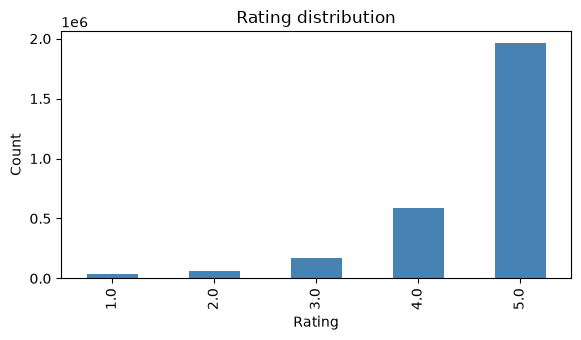

rating
1.0    0.014
2.0    0.021
3.0    0.061
4.0    0.209
5.0    0.696
Name: proportion, dtype: float64

Share of ratings >= 4.0: 90.5%


In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5))
df.rating.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Rating'); ax.set_ylabel('Count'); ax.set_title('Rating distribution')
plt.tight_layout(); plt.show()

print(df.rating.value_counts(normalize=True).sort_index().round(3))
print(f'\nShare of ratings >= {POS_THRESHOLD}: {(df.rating >= POS_THRESHOLD).mean():.1%}')

**Design decision.** We define **positive = rating ≥ 4**.

- For *training* the retrievers (BPR, two-tower with in-batch negatives), positives are the interactions the model tries to rank above sampled negatives — using 1–3★ interactions as "things this user wants" would teach the model to recommend books users disliked.
- For *evaluation* ground truth (Recall@K, NDCG@K on the test period), the same threshold applies: a hit only counts if the user actually liked the item.
- We keep sub-threshold interactions in the dataframe (flagged, not dropped): "user read but disliked" is still useful signal for ranking features later (e.g., user's average rating, activity counts).

Since ~85%+ of ratings are ≥ 4, this costs little data while keeping the target clean.

In [7]:
df['is_positive'] = (df.rating >= POS_THRESHOLD)
print(f'Positives: {df.is_positive.sum():,} ({df.is_positive.mean():.1%}) | Negatives kept as context: {(~df.is_positive).sum():,}')

Positives: 2,550,686 (90.5%) | Negatives kept as context: 267,618


## 5. Time-based train/validation/test split

**This is the split the whole project depends on** (random split = 0 on the grading criterion, and for good reason: a random split leaks future information — the model would train on Tuesday's interaction to "predict" Monday's, which no deployed system can do).

**Design decision:** *global* timestamp cutoffs at the 80th and 90th percentiles of interaction time:

- **Train** = interactions in (-∞, t₁) — model training
- **Validation** = [t₁, t₂) — hyperparameter tuning only (we never touch test until final evaluation)
- **Test** = [t₂, +∞) — final metrics, and it doubles as "recent user history" for the live webapp, simulating serving on activity the model never saw

We use global cutoffs (not per-user leave-last-out) because it matches deployment reality: a model trained at time t₁ serves *everyone* after t₁, including users who were barely active before. The dataset authors call this *absolute-timestamp splitting* and recommend it as the realistic strategy.

In [8]:
t1 = df.timestamp.quantile(TRAIN_Q)
t2 = df.timestamp.quantile(VAL_Q)

train = df[df.timestamp <  t1].copy()
val   = df[(df.timestamp >= t1) & (df.timestamp < t2)].copy()
test  = df[df.timestamp >= t2].copy()

for name, part in [('train', train), ('val', val), ('test', test)]:
    print(f'{name:5s}: {len(part):>9,} rows | {part.user_id.nunique():>8,} users | '
          f'{part.datetime.min().date()} -> {part.datetime.max().date()}')

# Sanity checks — no temporal overlap, full coverage
assert train.timestamp.max() < val.timestamp.min() <= val.timestamp.max() < test.timestamp.min()
assert len(train) + len(val) + len(test) == len(df)
print('\nSanity checks passed: splits are chronologically disjoint and complete.')

train: 2,254,643 rows |  127,585 users | 2020-10-20 -> 2022-10-25
val  :   281,830 rows |   67,770 users | 2022-10-25 -> 2023-01-26
test :   281,831 rows |   65,125 users | 2023-01-26 -> 2023-09-13

Sanity checks passed: splits are chronologically disjoint and complete.


In [9]:
# How many val/test users are known at training time? (the rest are cold — popularity fallback)
known = set(train.user_id)
for name, part in [('val', val), ('test', test)]:
    users = part.user_id.unique()
    frac = np.mean([u in known for u in users])
    print(f'{name}: {len(users):,} users, {frac:.1%} seen in train (rest = cold users -> popularity fallback)')

val: 67,770 users, 96.1% seen in train (rest = cold users -> popularity fallback)
test: 65,125 users, 91.9% seen in train (rest = cold users -> popularity fallback)


**Interpretation.** Some validation/test users never appear in training — that is *expected and realistic* under a time-based split (new users sign up after the model was trained). We evaluate personalized models on known users and route unknown users to the popularity fallback, exactly like the webapp will.

## 6. Exploratory analysis

### 6.1 Interaction volume over time (with split boundaries)

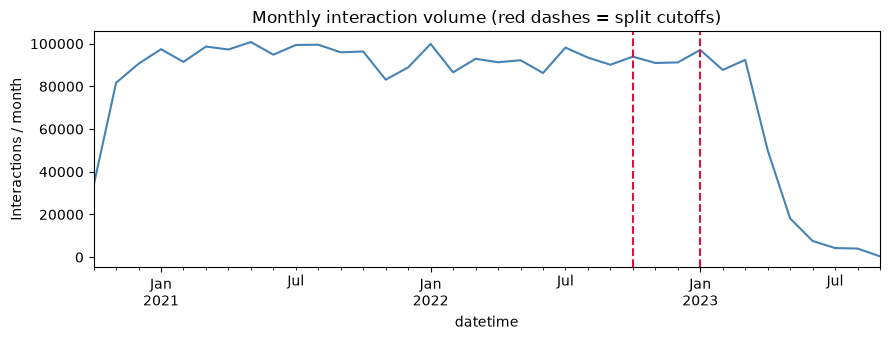

In [10]:
monthly = df.set_index('datetime').resample('ME').size()
fig, ax = plt.subplots(figsize=(9, 3.5))
monthly.plot(ax=ax, color='steelblue')
for t, label in [(t1, 'train | val'), (t2, 'val | test')]:
    ax.axvline(pd.to_datetime(t, unit='ms'), color='crimson', ls='--')
ax.set_title('Monthly interaction volume (red dashes = split cutoffs)')
ax.set_ylabel('Interactions / month')
plt.tight_layout(); plt.show()

### 6.2 User activity distribution (long tail, side 1)

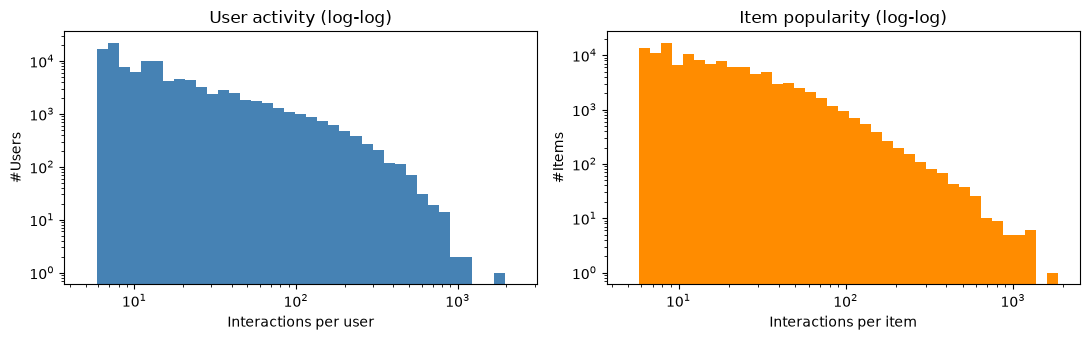

count    133221.0
mean         21.2
std          42.5
min           5.0
25%           6.0
50%           9.0
75%          17.0
max        2293.0
Name: count, dtype: Float64


In [11]:
user_counts = df.user_id.value_counts()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(user_counts, bins=np.logspace(np.log10(5), np.log10(user_counts.max()), 40), color='steelblue')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('Interactions per user'); axes[0].set_ylabel('#Users'); axes[0].set_title('User activity (log-log)')

item_counts = df.parent_asin.value_counts()
axes[1].hist(item_counts, bins=np.logspace(np.log10(5), np.log10(item_counts.max()), 40), color='darkorange')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('Interactions per item'); axes[1].set_ylabel('#Items'); axes[1].set_title('Item popularity (log-log)')
plt.tight_layout(); plt.show()

print(user_counts.describe().round(1))

### 6.3 The long tail — how concentrated is consumption?

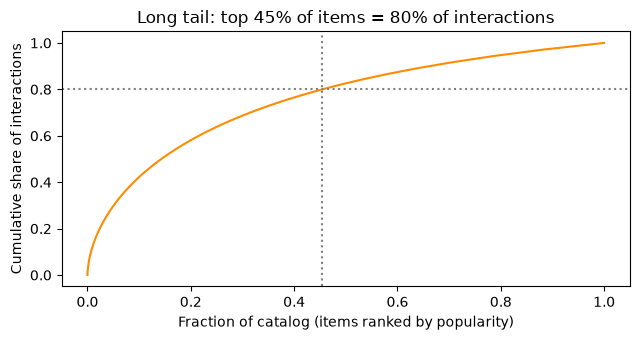

In [12]:
share = item_counts.sort_values(ascending=False).cumsum() / len(df)
share_np = share.to_numpy(dtype='float64')
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(np.arange(1, len(share) + 1) / len(share), share_np, color='darkorange')
ax.axhline(0.8, color='grey', ls=':')
top_for_80 = (share_np < 0.8).sum() / len(share)
ax.axvline(top_for_80, color='grey', ls=':')
ax.set_xlabel('Fraction of catalog (items ranked by popularity)')
ax.set_ylabel('Cumulative share of interactions')
ax.set_title(f'Long tail: top {top_for_80:.0%} of items = 80% of interactions')
plt.tight_layout(); plt.show()

**Interpretation.** A small head of the catalog concentrates most interactions — the classic long-tail pattern. Two consequences for us: (1) the **popularity baseline will be hard to beat** on Recall (it nails the head), and (2) **Catalog Coverage matters** as a metric: a model can score decent recall while recommending only the head. This is also why the professor asks for coverage everywhere, and it motivates the MMR-diversity bonus.

## 7. Encode IDs and export

We map raw string IDs to contiguous integer indices (**fit on train users/items only** — embedding tables are sized by the training vocabulary; val/test users unseen in train are handled by the popularity fallback, and unseen items simply can't be recommended by CF models). Splits are saved as parquet for the next notebooks.

In [13]:
user2idx = {u: i for i, u in enumerate(train.user_id.unique())}
item2idx = {it: i for i, it in enumerate(train.parent_asin.unique())}
print(f'Training vocab: {len(user2idx):,} users, {len(item2idx):,} items')

for part in (train, val, test):
    part['user_idx'] = part.user_id.map(user2idx).astype('Int64')
    part['item_idx'] = part.parent_asin.map(item2idx).astype('Int64')

train.to_parquet(os.path.join(DATA_DIR, 'train.parquet'), index=False)
val.to_parquet(os.path.join(DATA_DIR, 'val.parquet'), index=False)
test.to_parquet(os.path.join(DATA_DIR, 'test.parquet'), index=False)

import json as _json
with open(os.path.join(DATA_DIR, 'id_mappings.json'), 'w') as f:
    _json.dump({'user2idx': user2idx, 'item2idx': item2idx,
                'pos_threshold': POS_THRESHOLD, 't1': float(t1), 't2': float(t2)}, f)
print('Saved train/val/test parquet + id_mappings.json to', DATA_DIR)

Training vocab: 127,585 users, 120,573 items


Saved train/val/test parquet + id_mappings.json to ./data


## Next steps

- **02_baselines** — Random & Popularity recommenders + the shared evaluation pipeline (Recall@20/50, NDCG@10, Catalog Coverage) that every later model reuses.
- **03_mf_bpr** — matrix factorization with BPR pairwise loss, from scratch in PyTorch, popularity-based negative sampling.
- **04_two_tower** — user/item towers, in-batch negatives, softmax cross-entropy; FAISS indexing of item embeddings.
- **05_ranking** — 10+ engineered features, LightGBM LambdaRank on retrieved candidates.
- Item metadata (titles, cover images, categories) will be downloaded in 04/05 filtered to the ~surviving items, then loaded into PostgreSQL for the webapp.